<a href="https://colab.research.google.com/github/chizkidd/deep-learning-models/blob/main/tensorflow/lenet5-cifar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Deep Learning Models: A collection of various deep learning architectures, models, & their implementations (`PyTorch` or `TensorFlow`) in Jupyter Notebooks.
* Author: _Chizoba Obasi_
* Github Repo:

In [1]:
!pip install watermark

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 24.3 MB/s eta 0:00:00


In [2]:
%load_ext watermark
# %reload_ext watermark
%watermark -a 'Chizoba Obasi' -v -p torch

Author: Chizoba Obasi

Python implementation: CPython
Python version       : 3.12.12
IPython version      : 7.34.0

torch: 2.9.0+cu126



# Implementation of LeNet-5 for CIFAR-10 Image Classification
---

**LeNet-5** is a classic convolutional neural network employing the use of convolutions, pooling and fully connected layers that was developed in 1998 by _Yann Lecun, Leon Bottou, Yoshua Bengio & Patrick Haffner._ It was designed for handwritten digit recognition using the MNIST (Modified National Institute of Standards and Technology) dataset. <u>Animated demonstrations</u> of LeNet-5 can be found [here](https://yann.lecun.com/exdb/lenet/index.html). The original LeNet-5 paper, _**"Gradient Based Learning Applied to Document Recognition,"**_ can be found [here](http://vision.stanford.edu/cs598_spring07/papers/Lecun98.pdf) or [here](https://yann.lecun.com/exdb/publis/pdf/lecun-01a.pdf). According to Yann Lecun, on his LeNet5 [demo](https://yann.lecun.com/exdb/lenet/index.html) page:
>Convolutional Neural Networks are are a special kind of multi-layer neural networks. Like almost every other neural networks they are trained with a version of the back-propagation algorithm. Where they differ is in the architecture.
>  
>Convolutional Neural Networks are designed to recognize visual patterns directly from pixel images with minimal preprocessing. They can recognize patterns with extreme variability (such as handwritten characters), and with robustness to distortions and simple geometric transformations.
>
>LeNet-5 is our latest convolutional network designed for handwritten and machine-printed character recognition.


The goal is to reproduce the LeNet-5 model on the [CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html) dataset in tensorflow as seen in the 1998 paper. To improve accuracy, further modifications that leverage current deep learning advancements will be done to the model. The details for the CIFAR-10 dataset are shown below:
- 60000 32x32 color images
- 10 classes (6000 images per class)
- 50,000 training images
- 10,000 test images
- <u>Classes:</u> **airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck**
- All the classes are mutually exclusive.
  -  There is no overlap between automobiles and trucks.
  - "Automobile" includes sedans, SUVs, things of that sort.
  - "Truck" includes only big trucks.
  - Neither includes pickup trucks.


This notebook implements the classic LeNet-5 convolutional network [1] and applies it to CIFAR-10 image classification. The basic LeNet-5 architecture is shown in the figure below:

![LeNet5 model architecture](http://drive.google.com/uc?export=download&id=14om5xslwvpxqhQZqPGqwjMoOYiqpYnM1)



LeNet-5 is commonly regarded as the pioneer of convolutional neural networks, consisting of a very simple architecture (by modern standards). **The LeNet-5 architecture primarily consists of three major layer constructs:**
* Convolutional layers, `C1, C3, C5`
* Sub-sampling layers (pooling), `S2, S4`
* Fully-connected layers (FC), `F6`

In the figure above, convolutional layers are labeled $Cx$, sub-sampling layers are labeled $Sx$, and fully-connected layers are labeled $Fx$, where $x$ is the layer index. In total, LeNet-5 consists of only $7$ layers. $3$ out of these $7$ layers are convolutional layers ($C1, C3, C5$), which are connected by two average pooling layers ($S2, S4$). The penultimate layer is a fully connected layer ($F6$), which is followed by the final output layer. The additional details are summarized below with respect to the CIFAR-10 dataset:
```
Model:                   Input --> [  C1  ] -> [  S2  ] -> [  C3  ] -> [  S4  ] -----------> [  C5/F5  ] -> [  F6  ] -> Output
Shape:                   32x32       32x32       16x16       12x12        6x6                    1x1          84          10
Feature Maps:              3           6           6          16          16                     120          -           -
Trainable Params:          -          456          -         2,416         -                    69,240       10,164       850

Implementation:                    ConvNet -> Avg. Pool -> ConvNet -> Avg. Pool -> (Flatten) ---> FC ---------> FC -----> Softmax
```

- The input size is $32\times32\times3$.
- All convolutional layers use $5\times5$ kernels with stride $1$.
- The two average pooling (subsampling) layers are $2\times2$ pixels wide with stride $2$.
- The output layer uses $10$ custom `Euclidean Radial Basis Function (RBF)` neurons for the output layer. (**In this notebook, we replace these with `softmax` activations**).


---
### References

- [1] Y. LeCun, L. Bottou, Y. Bengio, and P. Haffner. Gradient-based learning applied to document recognition. Proceedings of the IEEE, november 1998.

---

In [3]:
import tensorflow as tf
from tensorflow import keras
from keras.datasets import cifar10
from keras.layers import Input, Conv2D, AveragePooling2D, MaxPooling2D, Dense, Flatten, Dropout, Activation, BatchNormalization
from keras.models import Model, Sequential
from keras.optimizers import Adam
from keras.utils import to_categorical
# from keras.preprocessing.image import ImageDataGenerator
from keras.regularizers import l2
from keras.callbacks import Callback, ReduceLROnPlateau
from sklearn.model_selection import train_test_split

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
%matplotlib inline

import pandas as pd
import numpy as np
import math
import time

In [4]:
print(tf.__version__)

2.19.0


In [5]:
# Check if GPU is available
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("Num GPUs Available: ", len(gpus))
    for gpu in gpus:
        print(f"GPU: {gpu}")
else:
    print("No GPU available.")


#------------------------------------------------------------------------------------------------------------------------
# Verify TensorFlow is using GPU
if tf.test.gpu_device_name():
    print('GPU found: {}'.format(tf.test.gpu_device_name()))
else:
    print("GPU not found.")

Num GPUs Available:  1
GPU: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
GPU found: /device:GPU:0


---
# 0. Model Settings

---

In [6]:
##########################
### SETTINGS
##########################

# Hyperparameters
RANDOM_SEED = 42
LEARNING_RATE = 0.001
BATCH_SIZE = 128
NUM_EPOCHS = 30

# Architecture
INPUT_SHAPE = (32, 32, 3) # CIFAR-10 is 32x32 pixels, 3 color channels
NUM_CLASSES = 10

# Other
GRAYSCALE = False

---
# 1. Data Preparation & Loading

---

In [7]:
# 1. Load the CIFAR-10 data
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train.shape, type(x_train)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


((50000, 32, 32, 3), numpy.ndarray)

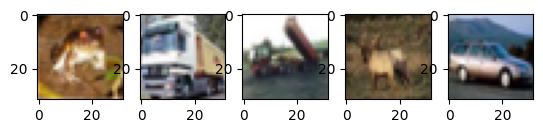

In [8]:
for i in range(5):
  plt.subplot(1, 5, i+1)
  plt.imshow(x_train[i, :, :])

In [9]:
def preprocess_data(cifar_data, split_ratio=0.08, batch_size=32, num_classes=10, preprocess_type='normalize', random_seed=42):
    """
    Preprocess CIFAR-10 data with specified method and return TensorFlow datasets.

    Args:
        cifar_data: Tuple containing the CIFAR-10 data.
        # ... (rest of args remain the same)
    """
    (train_images, train_labels), (test_images, test_labels) = cifar_data

    # Convert to float32 (important for normalization)
    train_images = train_images.astype('float32')
    test_images = test_images.astype('float32')

    # Note: No need to reshape/resize as CIFAR-10 is already (32, 32, 3)

    if preprocess_type == 'normalize':
        # Normalize pixel values to [0, 1]
        train_images = train_images / 255.0
        test_images = test_images / 255.0

    elif preprocess_type == 'standardize':
        # Standardize pixel values (mean 0, std 1)
        mean_px = tf.reduce_mean(train_images).numpy().astype(float)
        std_px = tf.math.reduce_std(train_images).numpy().astype(float)

        train_images = (train_images - mean_px) / std_px
        test_images = (test_images - mean_px) / std_px

    else:
        raise ValueError("Invalid preprocess_type. Choose 'normalize' or 'standardize'.")

    # Convert labels to one-hot encoding (10 classes for CIFAR-10)
    train_labels = to_categorical(train_labels, num_classes=num_classes)
    test_labels = to_categorical(test_labels, num_classes=num_classes)

    # Split the training data into training and validation sets
    num_val_samples = int(split_ratio * len(train_images))
    val_images = train_images[-num_val_samples:]
    val_labels = train_labels[-num_val_samples:]
    train_images = train_images[:-num_val_samples]
    train_labels = train_labels[:-num_val_samples]

    # Create TensorFlow datasets
    train_dataset = tf.data.Dataset.from_tensor_slices((train_images, train_labels))
    val_dataset = tf.data.Dataset.from_tensor_slices((val_images, val_labels))
    test_dataset = tf.data.Dataset.from_tensor_slices((test_images, test_labels))

    # Shuffle and batch datasets
    train_dataset = train_dataset.shuffle(buffer_size=len(train_images), seed=random_seed).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    val_dataset = val_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    test_dataset = test_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return train_dataset, val_dataset, test_dataset

In [10]:
# Load CIFAR data
mnist_data = cifar10.load_data()

# Preprocess data with normalization and a fixed random seed
train_dataset, val_dataset, test_dataset = preprocess_data(
    mnist_data, split_ratio=0.08, batch_size=BATCH_SIZE,
    num_classes=NUM_CLASSES,preprocess_type='normalize',
    random_seed=RANDOM_SEED)


In [11]:
# Assuming train_dataset is your tf.data.Dataset
for images, labels in train_dataset.take(1):  # Take one batch
    print("Image shape:", images.shape)
    print("Label shape:", labels.shape)

Image shape: (128, 32, 32, 3)
Label shape: (128, 10)


---
# 2. Model Creation

---

In [12]:
def LeNet5(input_shape, num_classes):
    model = Sequential([
        # C1: Convolutional Layer (6 filters)
        Conv2D(6, kernel_size=(5, 5), strides=(1, 1), activation='tanh',
               input_shape=input_shape, padding='same'), # Input shape is (32, 32, 3)

        # S2: Pooling Layer (2x2 average pooling)
        AveragePooling2D(pool_size=(2, 2), strides=(2, 2)),

        # C3: Convolutional Layer (16 filters)
        Conv2D(16, kernel_size=(5, 5), strides=(1, 1), activation='tanh', padding='valid'),

        # S4: Pooling Layer (2x2 average pooling)
        AveragePooling2D(pool_size=(2, 2), strides=(2, 2)),

        # C5: Fully Connected Convolutional Layer (120 units)
        Flatten(),
        Dense(120, activation='tanh'),

        # F6: Fully Connected Layer (84 units)
        Dense(84, activation='tanh'),

        # Output Layer (10 units for CIFAR-10)
        Dense(num_classes, activation='softmax')
    ])
    return model

---
# 3. Model Compiling, Training, Testing & Evaluation

---

In [13]:
def train_model(model, train_dataset, val_dataset, NUM_EPOCHS=20, lr_factor=0.2, lr_patience=2):
    # Compile the model
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    class LogMetrics(Callback):
        def __init__(self, num_epochs):
            super(LogMetrics, self).__init__()
            self.num_epochs = num_epochs
            self.lrs = []

        def on_train_begin(self, logs=None):
            self.lrs = []

        def on_epoch_end(self, epoch, logs=None):
            # Val metrics are available in logs thanks to validation_data=val_dataset
            val_loss = logs.get('val_loss')
            val_accuracy = logs.get('val_accuracy')
            lr = self.model.optimizer.learning_rate.numpy()
            self.lrs.append(lr)

            print(f'Epoch {epoch + 1}/{self.num_epochs} | '
                  f'Train Loss: {logs["loss"]:.5f}, '
                  f'Train Accuracy: {logs["accuracy"]:.5f} | '
                  f'Val Loss: {val_loss:.5f}, '
                  f'Val Accuracy: {val_accuracy:.5f} | '
                  f'Learning Rate: {lr:.8f}')

    # Define the ReduceLROnPlateau callback
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=lr_factor,
        patience=lr_patience,
        verbose=1
    )

    # Create an instance of the LogMetrics callback
    log_metrics = LogMetrics(NUM_EPOCHS)

    # Train the model
    start_time = time.time()
    history = model.fit(train_dataset,
                        epochs=NUM_EPOCHS,
                        validation_data=val_dataset,
                        callbacks=[log_metrics, reduce_lr],
                        verbose=0) # verbosity is 0 since logging is handled by LogMetrics

    print('Total Training Time: %.2f min' % ((time.time() - start_time)/60))
    return model, history, log_metrics, reduce_lr

In [14]:
# Plot the training history
def plot_history(history, lrs):
    epochs = range(len(history.history['loss']))

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 3, 1)
    plt.plot(epochs, history.history['loss'], label='Training Loss')
    plt.plot(epochs, history.history['val_loss'], label='Validation Loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(epochs, history.history['accuracy'], label='Training Accuracy')
    plt.plot(epochs, history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(epochs, lrs, label='Learning Rate')
    plt.title('Learning Rate')
    plt.xlabel('Epochs')
    plt.ylabel('Learning Rate')
    plt.legend()

    plt.tight_layout()
    plt.show()

In [15]:
# Instantiate the model with CIFAR-10 parameters
model = LeNet5(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 6)      │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 16, 16, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 12, 12, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 6, 6, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        69,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83,126 (324.71 KB)

 Trainable params: 83,126 (324.71 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30 | Train Loss: 1.83679, Train Accuracy: 0.34946 | Val Loss: 1.72389, Val Accuracy: 0.39625 | Learning Rate: 0.00100000
Epoch 2/30 | Train Loss: 1.65670, Train Accuracy: 0.41693 | Val Loss: 1.61085, Val Accuracy: 0.43525 | Learning Rate: 0.00100000
Epoch 3/30 | Train Loss: 1.53259, Train Accuracy: 0.45780 | Val Loss: 1.51253, Val Accuracy: 0.47250 | Learning Rate: 0.00100000
Epoch 4/30 | Train Loss: 1.43668, Train Accuracy: 0.49283 | Val Loss: 1.43782, Val Accuracy: 0.49250 | Learning Rate: 0.00100000
Epoch 5/30 | Train Loss: 1.37036, Train Accuracy: 0.51441 | Val Loss: 1.40698, Val Accuracy: 0.49800 | Learning Rate: 0.00100000
Epoch 6/30 | Train Loss: 1.31040, Train Accuracy: 0.53789 | Val Loss: 1.34171, Val Accuracy: 0.52325 | Learning Rate: 0.00100000
Epoch 7/30 | Train Loss: 1.26024, Train Accuracy: 0.55272 | Val Loss: 1.32000, Val Accuracy: 0.52925 | Learning Rate: 0.00100000
Epoch 8/30 | Train Loss: 1.21896, Train Accuracy: 0.57041 | Val Loss: 1.30226, Val Accuracy: 0.53

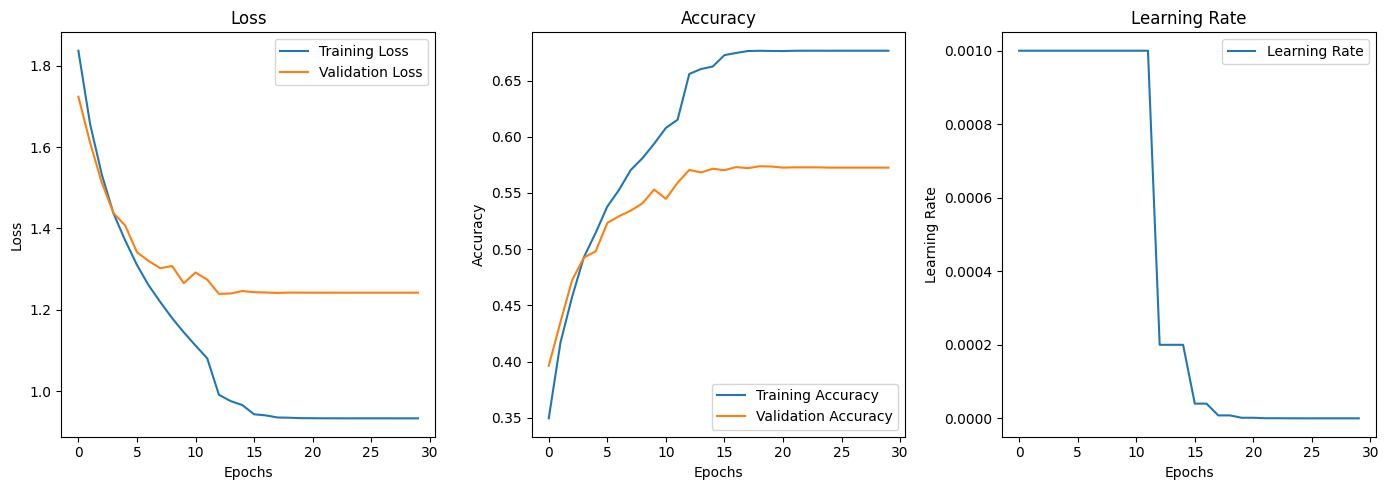

In [16]:
NUM_EPOCHS = 30 # A higher number is often needed for CIFAR-10

model, history, log_metrics, reduce_lr = train_model(model, train_dataset, val_dataset, NUM_EPOCHS=NUM_EPOCHS)

# Evaluate on test data
test_loss, test_accuracy = model.evaluate(test_dataset)
print(f'\nTest Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}')

# Plot loss and accuracy of training and validation dataset
plot_history(history, log_metrics.lrs)

---
# 4. Model Improvement: Scaling Factor Via Kernels

---

In [17]:
def scaled_LeNet5(input_shape, num_classes):

    # 1. Determine the channel factor (3 for CIFAR-10)
    channel_factor = input_shape[-1]

    # 2. Define the scaled kernel counts based on the channel factor
    C1_KERNELS = 6 * channel_factor      # 6 * 3 = 18 kernels
    C3_KERNELS = 16 * channel_factor     # 16 * 3 = 48 kernels
    FC5_UNITS = 120 * channel_factor     # 120 * 3 = 360 units
    F6_UNITS = 84 * channel_factor       # 84 * 3 = 252 units

    model = Sequential([
        # C1: Convolutional Layer
        Conv2D(C1_KERNELS, kernel_size=(5, 5), strides=(1, 1), activation='tanh',
               input_shape=input_shape, padding='same'),

        # S2: Pooling Layer
        AveragePooling2D(pool_size=(2, 2), strides=(2, 2)),

        # C3: Convolutional Layer
        Conv2D(C3_KERNELS, kernel_size=(5, 5), strides=(1, 1), activation='tanh', padding='valid'),

        # S4: Pooling Layer
        AveragePooling2D(pool_size=(2, 2), strides=(2, 2)),

        # --- Classifier Block ---

        # Flatten before Dense layers
        Flatten(),

        # C5 / FC5: Fully Connected Layer
        Dense(FC5_UNITS, activation='tanh'),

        # F6: Fully Connected Layer
        Dense(F6_UNITS, activation='tanh'),

        # Output Layer
        Dense(num_classes, activation='softmax')
    ])
    return model


In [18]:

# Make model and print model summary
scaled_model = scaled_LeNet5(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES)
scaled_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 18)     │         1,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 16, 16, 18)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 48)     │        21,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 6, 6, 48)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1728)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 360)            │       622,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 252)            │        90,972 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 738,958 (2.82 MB)

 Trainable params: 738,958 (2.82 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30 | Train Loss: 1.81723, Train Accuracy: 0.36102 | Val Loss: 1.70598, Val Accuracy: 0.40725 | Learning Rate: 0.00100000
Epoch 2/30 | Train Loss: 1.61699, Train Accuracy: 0.43233 | Val Loss: 1.53548, Val Accuracy: 0.45850 | Learning Rate: 0.00100000
Epoch 3/30 | Train Loss: 1.43743, Train Accuracy: 0.49243 | Val Loss: 1.42030, Val Accuracy: 0.50275 | Learning Rate: 0.00100000
Epoch 4/30 | Train Loss: 1.32601, Train Accuracy: 0.52996 | Val Loss: 1.34873, Val Accuracy: 0.53525 | Learning Rate: 0.00100000
Epoch 5/30 | Train Loss: 1.23194, Train Accuracy: 0.56393 | Val Loss: 1.32295, Val Accuracy: 0.53975 | Learning Rate: 0.00100000
Epoch 6/30 | Train Loss: 1.13641, Train Accuracy: 0.59915 | Val Loss: 1.28621, Val Accuracy: 0.53625 | Learning Rate: 0.00100000
Epoch 7/30 | Train Loss: 1.04046, Train Accuracy: 0.63335 | Val Loss: 1.27539, Val Accuracy: 0.55200 | Learning Rate: 0.00100000
Epoch 8/30 | Train Loss: 0.95038, Train Accuracy: 0.66633 | Val Loss: 1.28658, Val Accuracy: 0.55

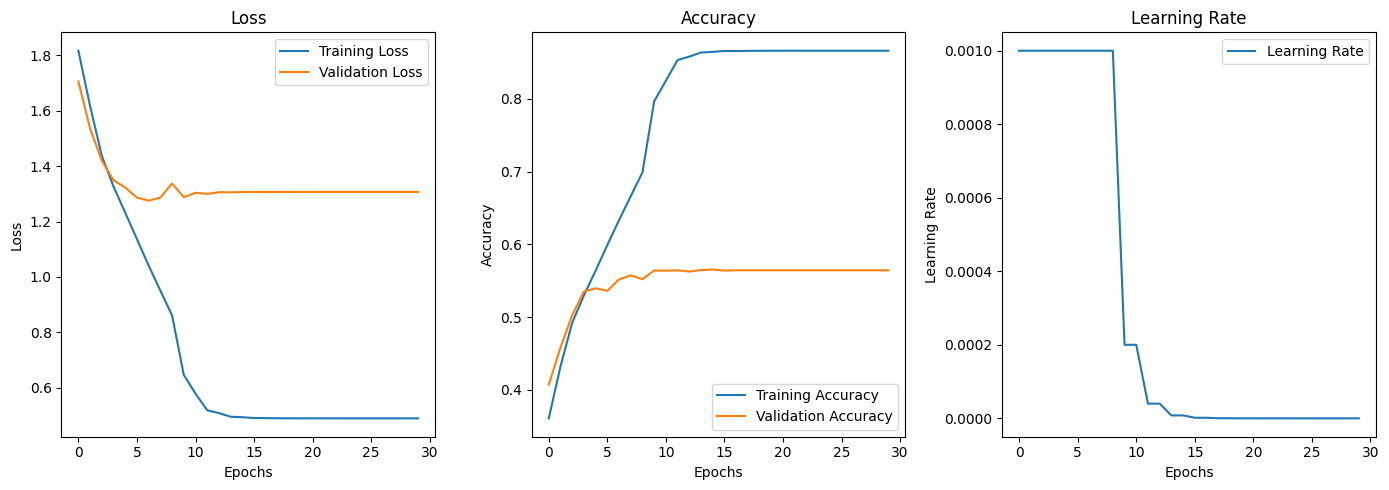

In [19]:
scaled_model, history_scaled, log_metrics_scaled, reduce_lr_scaled = train_model(scaled_model, train_dataset, val_dataset, NUM_EPOCHS=NUM_EPOCHS)

# Evaluate on test data
test_loss_scaled, test_acc_scaled = scaled_model.evaluate(test_dataset)
print(f'\nTest Loss: {test_loss_scaled:.4f}, Test Accuracy: {test_acc_scaled:.4f}')

# Plot loss and accuracy of training and validation dataset
plot_history(history_scaled, log_metrics_scaled.lrs)

---
# 5. Model Improvements 2

---
The changes made are listed below:

1.   Replace all instances of `tanh` activation function with `ReLU` except the final output layer.
2.   Replace all instances of `AveragePooling2D` to `MaxPooling2D`
3.   Add `Dropout()` after 2nd pooling layer and the fully connected (FC) layer.
4.  Add `BatchNormalization()` after every `Conv2D` layer and potentially the fully connected layer.



In [20]:
def LeNet5v1(input_shape, num_classes):

    # Use 3 channels for CIFAR-10
    channel_factor = input_shape[-1]

    # Scaled kernel/unit counts
    C1_KERNELS = 6 * channel_factor     # 18
    C3_KERNELS = 16 * channel_factor    # 48
    FC5_UNITS = 120 * channel_factor    # 360
    F6_UNITS = 84 * channel_factor      # 252

    model = Sequential([
        # C1: Convolutional Layer
        Conv2D(C1_KERNELS, kernel_size=(5, 5), strides=(1, 1), activation='relu', # <--- RELU
               input_shape=input_shape, padding='same'),
        BatchNormalization(), # <--- BATCH NORM

        # S2: Pooling Layer
        MaxPooling2D(pool_size=(2, 2), strides=(2, 2)), # <--- MAX POOL

        # C3: Convolutional Layer
        Conv2D(C3_KERNELS, kernel_size=(5, 5), strides=(1, 1), activation='relu', padding='valid'), # <--- RELU
        BatchNormalization(), # <--- BATCH NORM

        # S4: Pooling Layer
        MaxPooling2D(pool_size=(2, 2), strides=(2, 2)), # <--- MAX POOL
        Dropout(0.25), # <--- DROPOUT

        # --- Classifier Block ---

        Flatten(),

        # C5 / FC5: Fully Connected Layer
        Dense(FC5_UNITS, activation='relu'), # <--- RELU
        BatchNormalization(), # <--- BATCH NORM
        Dropout(0.5), # <--- DROPOUT (higher rate for dense layers)

        # F6: Fully Connected Layer
        Dense(F6_UNITS, activation='relu'), # <--- RELU

        # Output Layer
        Dense(num_classes, activation='softmax')
    ])
    return model


In [21]:
# Create the model & Print out model summary
LeNet5v1_model = LeNet5v1(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES)
LeNet5v1_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 18)     │         1,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 18)     │            72 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 18)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 48)     │        21,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 12, 12, 48)     │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 48)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 6, 48)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1728)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 360)            │       622,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 360)            │         1,440 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 360)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 252)            │        90,972 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         2,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 740,662 (2.83 MB)

 Trainable params: 739,810 (2.82 MB)

 Non-trainable params: 852 (3.33 KB)

Epoch 1/30 | Train Loss: 1.59406, Train Accuracy: 0.43920 | Val Loss: 2.47672, Val Accuracy: 0.27225 | Learning Rate: 0.00100000
Epoch 2/30 | Train Loss: 1.21191, Train Accuracy: 0.56739 | Val Loss: 1.18049, Val Accuracy: 0.58950 | Learning Rate: 0.00100000
Epoch 3/30 | Train Loss: 1.04978, Train Accuracy: 0.62709 | Val Loss: 1.35616, Val Accuracy: 0.53150 | Learning Rate: 0.00100000
Epoch 4/30 | Train Loss: 0.95053, Train Accuracy: 0.66383 | Val Loss: 1.20760, Val Accuracy: 0.58400 | Learning Rate: 0.00100000

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
Epoch 5/30 | Train Loss: 0.80926, Train Accuracy: 0.71311 | Val Loss: 0.83167, Val Accuracy: 0.70100 | Learning Rate: 0.00020000
Epoch 6/30 | Train Loss: 0.76674, Train Accuracy: 0.72774 | Val Loss: 0.76492, Val Accuracy: 0.73350 | Learning Rate: 0.00020000
Epoch 7/30 | Train Loss: 0.73996, Train Accuracy: 0.73639 | Val Loss: 0.74089, Val Accuracy: 0.74050 | Learning Rate: 0.00020000
Epoch 8/30 | Train 

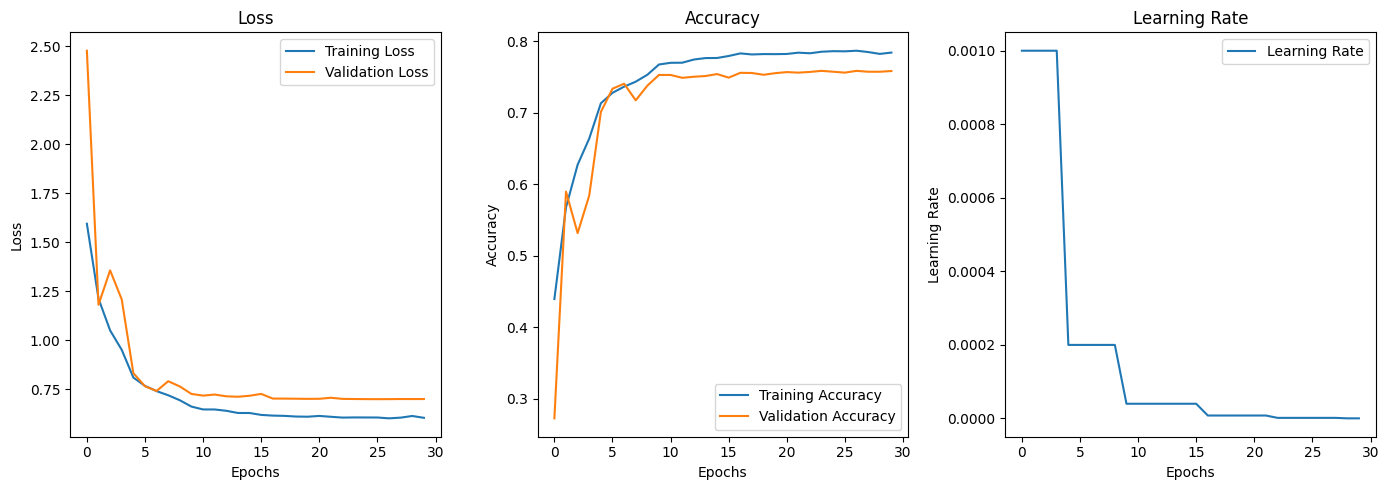

In [22]:
LeNet5v1_model, history_v1, log_metrics_v1, reduce_lr_v1 = train_model(LeNet5v1_model, train_dataset, val_dataset, NUM_EPOCHS=NUM_EPOCHS)

# Evaluate on test data using model
test_loss_v1, test_accuracy_v1 = LeNet5v1_model.evaluate(test_dataset)
print(f'Test Loss: {test_loss_v1:.4f}, Test Accuracy: {test_accuracy_v1:.4f}')

# Plot loss and accuracy of training and validation dataset
plot_history(history_v1, log_metrics_v1.lrs)

In [23]:
%watermark -iv

keras     : 3.10.0
matplotlib: 3.10.0
tensorflow: 2.19.0
pandas    : 2.2.2
numpy     : 2.0.2
sklearn   : 1.6.1

